##Solution Pipeline
### Project 2: Credit Card Fraud Detection

**Install Dependencies**

In [1]:
!pip install pymongo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 26.3 MB/s eta 0:00:00


**Imports**

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from pymongo import MongoClient
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score
)

**Data Preparation** (Query MongoDB)

In [3]:
#Query the transactions collection and flatten nested fields into a dataframe.
#set Atlas connection string here
MONGO_URI = 'connection string here'
#connect and pull all documents
client = MongoClient(MONGO_URI, serverSelectionTimeoutMS=5000)
collection = client["fraud_detection"]["transactions"]

#query all documents and flatten the nested pca_features sub-document
#exclude _id and only pull fields needed for the model
cursor = collection.find({}, {"_id": 0})
records = list(cursor)
client.close()

#flatten nested pca_features dict into top-level columns (V1–V28)
for rec in records:
    rec.update(rec.pop("pca_features", {}))
    rec.pop("cardholder", None)   # drop cardholder sub-doc (not used in model)
    rec.pop("merchant", None)     # drop merchant sub-doc (not used in model)
    rec.pop("transaction_id", None)

df = pd.DataFrame(records)
df.head()

,time,amount,class,V1,V2,V3,V4,V5,V6,V7,...,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28
0,0,149.62,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,...,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053
1,0,2.69,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,...,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724
2,1,378.66,0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,...,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752
3,1,123.50,0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,...,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458
4,2,69.99,0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,...,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153


**Data Preparation**

Feature / Label Split & SMOTE

**Rationale:** The dataset is severely imbalanced (~0.17% fraud). I applied SMOTE on the training set only to synthetically oversample the minority class so the model learns to detect fraud rather than always predict legitimate. Don't apply SMOTE to the test set.

In [4]:
#features: Time, Amount, V1–V28
FEATURE_COLS = ["time", "amount"] + [f"V{i}" for i in range(1, 29)]
TARGET_COL = "class"

X = df[FEATURE_COLS]
y = df[TARGET_COL]

#train/test split — stratified to preserve fraud ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")
print(f"Fraud in train (before SMOTE): {y_train.sum()} ({y_train.mean():.4%})")

#apply SMOTE to training set only
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

Train size: 226980 | Test size: 56746
Fraud in train (before SMOTE): 378 (0.1665%)


**Model**

Random Forest Classifier

**Rationale:** Random Forest is the standard baseline for credit card fraud detection (see background reading). It handles class imbalance well, is robust to outliers in `Amount`, and produces feature importances that help explain predictions — important for a model prioritizing cardholder trust.

In [5]:
# Train a Random Forest with 100 trees
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_res, y_train_res)

# Predict on the held-out test set
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=["Legitimate", "Fraud"]))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob):.4f}")

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56651
       Fraud       0.90      0.77      0.83        95

    accuracy                           1.00     56746
   macro avg       0.95      0.88      0.91     56746
weighted avg       1.00      1.00      1.00     56746

AUC-ROC: 0.9608


**Visualize Results**

**Rationale:** The confusion matrix directly shows the trade-off between false positives and false negatives. False positives are legitimate transactions wrongly declined which is bad for cardholder experience. False negatives are fraud missed which is bad for financial loss. This is the core tension of the problem statement and the most meaningful visualization for stakeholders.

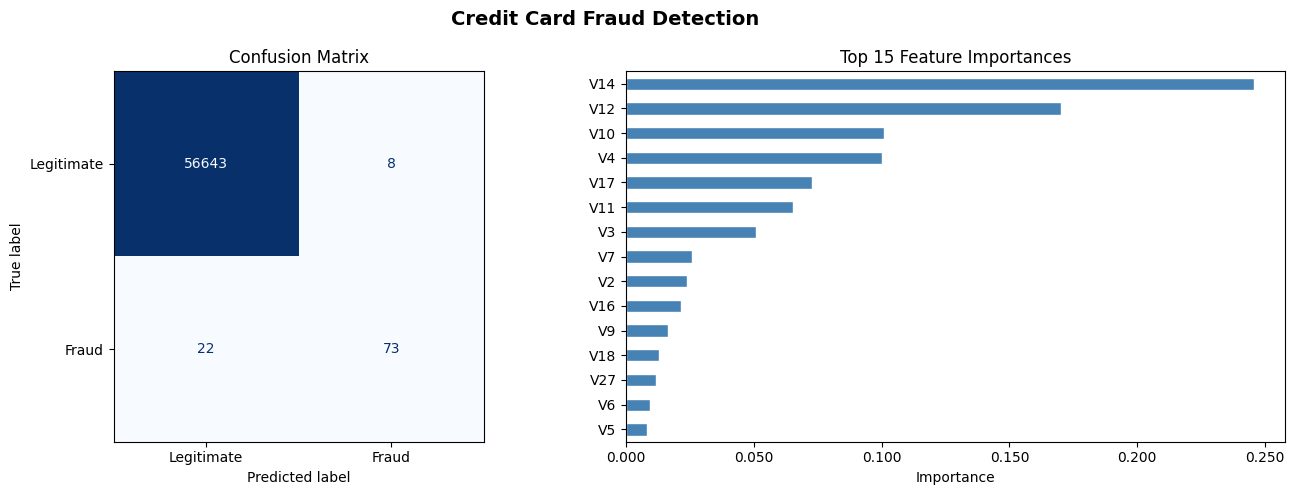

Figure saved to fraud_results.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Credit Card Fraud Detection", fontsize=14, fontweight="bold")

# plotting Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Legitimate", "Fraud"])
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix", fontsize=12)

#Top 15 Feature Importances
importances = pd.Series(rf.feature_importances_, index=FEATURE_COLS)
top15 = importances.sort_values(ascending=True).tail(15)
top15.plot(kind="barh", ax=axes[1], color="steelblue", edgecolor="white")
axes[1].set_title("Top 15 Feature Importances", fontsize=12)
axes[1].set_xlabel("Importance")
axes[1].xaxis.set_major_formatter(mtick.FormatStrFormatter("%.3f"))

plt.tight_layout()
plt.savefig("fraud_results.png", dpi=150, bbox_inches="tight")
plt.show()